## Exercise 7.01: Loading and Understanding the data

### 1.1 import thư viện

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 1.2. Đọc file csv và mô tả dataset

In [110]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                 'PacktWorkshops/'\
                 'The-Data-Analysis-Workshop/master/'\
                 'Chapter07/Dataset/heart.csv')


In [111]:
df.describe()
#mục đích của describe() : để hiểu dữ liệu nằm trong range nào, có outlier không, phân bố ra sao

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


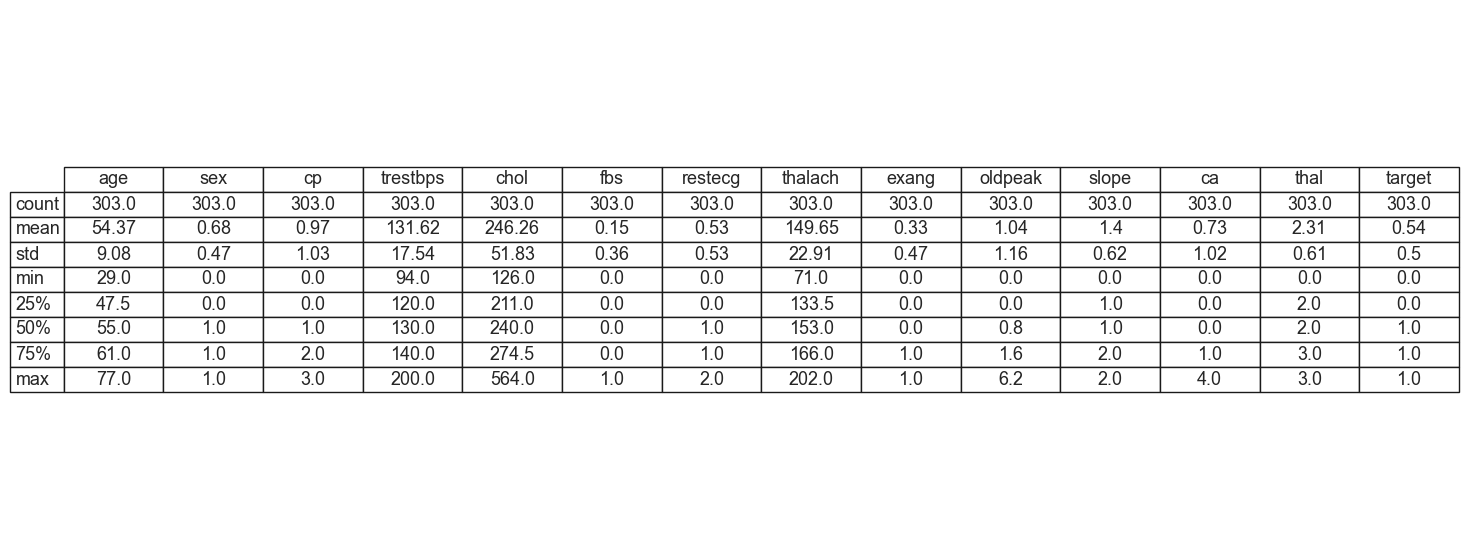

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

stats = df.describe().round(2) # Làm tròn cho đẹp

fig, ax = plt.subplots(figsize=(12, 7)) 
ax.axis('off') # Ẩn trục tọa độ

# Tạo bảng
tbl = ax.table(cellText=stats.values, 
               colLabels=stats.columns, 
               rowLabels=stats.index,
               loc='center', 
               cellLoc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.5, 1.5) # Chỉnh kích thước bảng

plt.savefig('describe_output.png', bbox_inches='tight', dpi=300)
plt.show()

In [113]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [114]:
df.rename(index = str, \
          columns = {'cp' : 'chest_pain', \
                     'trestbps' : 'rest_bp', \
                     'fbs' : 'fast_bld_sugar', \
                     'restecg' : 'rest_ecg', \
                     'thalach' : 'max_hr', \
                     'exang' : 'ex_angina', \
                     'oldpeak' : 'st_depr', \
                     'ca' : 'colored_vessels', \
                     'thal' : 'thalassemia', }, inplace = True)


In [115]:
df.info()

<class 'pandas.DataFrame'>
Index: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              303 non-null    int64  
 1   sex              303 non-null    int64  
 2   chest_pain       303 non-null    int64  
 3   rest_bp          303 non-null    int64  
 4   chol             303 non-null    int64  
 5   fast_bld_sugar   303 non-null    int64  
 6   rest_ecg         303 non-null    int64  
 7   max_hr           303 non-null    int64  
 8   ex_angina        303 non-null    int64  
 9   st_depr          303 non-null    float64
 10  slope            303 non-null    int64  
 11  colored_vessels  303 non-null    int64  
 12  thalassemia      303 non-null    int64  
 13  target           303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.5+ KB


Đây là bước hiểu nội dung :
- Ở dữ liệu này, chúng ta có thể thấy có 303 mẫu với 14 đặc trưng và tất cả đăc trưng thuộc loại biến số (numeric) và biến mục tiêu là biến phân loại binary.

- age: tuổi
- sex: giới tính
- cp : đau ngực (4 loại)
- trestbps : huyết áp
- chol: cholesterol - huyết thanh 
- fbs : đường huyết lúc đói có lớn hơn 120mg/dl
- restecg : điện tâm đồ lúc nghỉ (3 loại)
- thalach : nhịp tim
- exang : đau thắt ngực khi gắng sức 
- oldpeak : mức chênh xuống của đoạn ST do gắng sức so với trạng thái nghỉ 
- slope : độ dốc đoạn ST ở mức gắng sức cao nhất (3 loại )
- ca : số lượng máu lớn được nhuộm màu bằng phương pháp huỳnh quang
- thal : bệnh tan máu bẩm sinh 


In [116]:
df.isnull().sum()

age                0
sex                0
chest_pain         0
rest_bp            0
chol               0
fast_bld_sugar     0
rest_ecg           0
max_hr             0
ex_angina          0
st_depr            0
slope              0
colored_vessels    0
thalassemia        0
target             0
dtype: int64

đa phần bộ dữ liệu này không có giá trị null


## Exercise 7.02: Checking for outliers

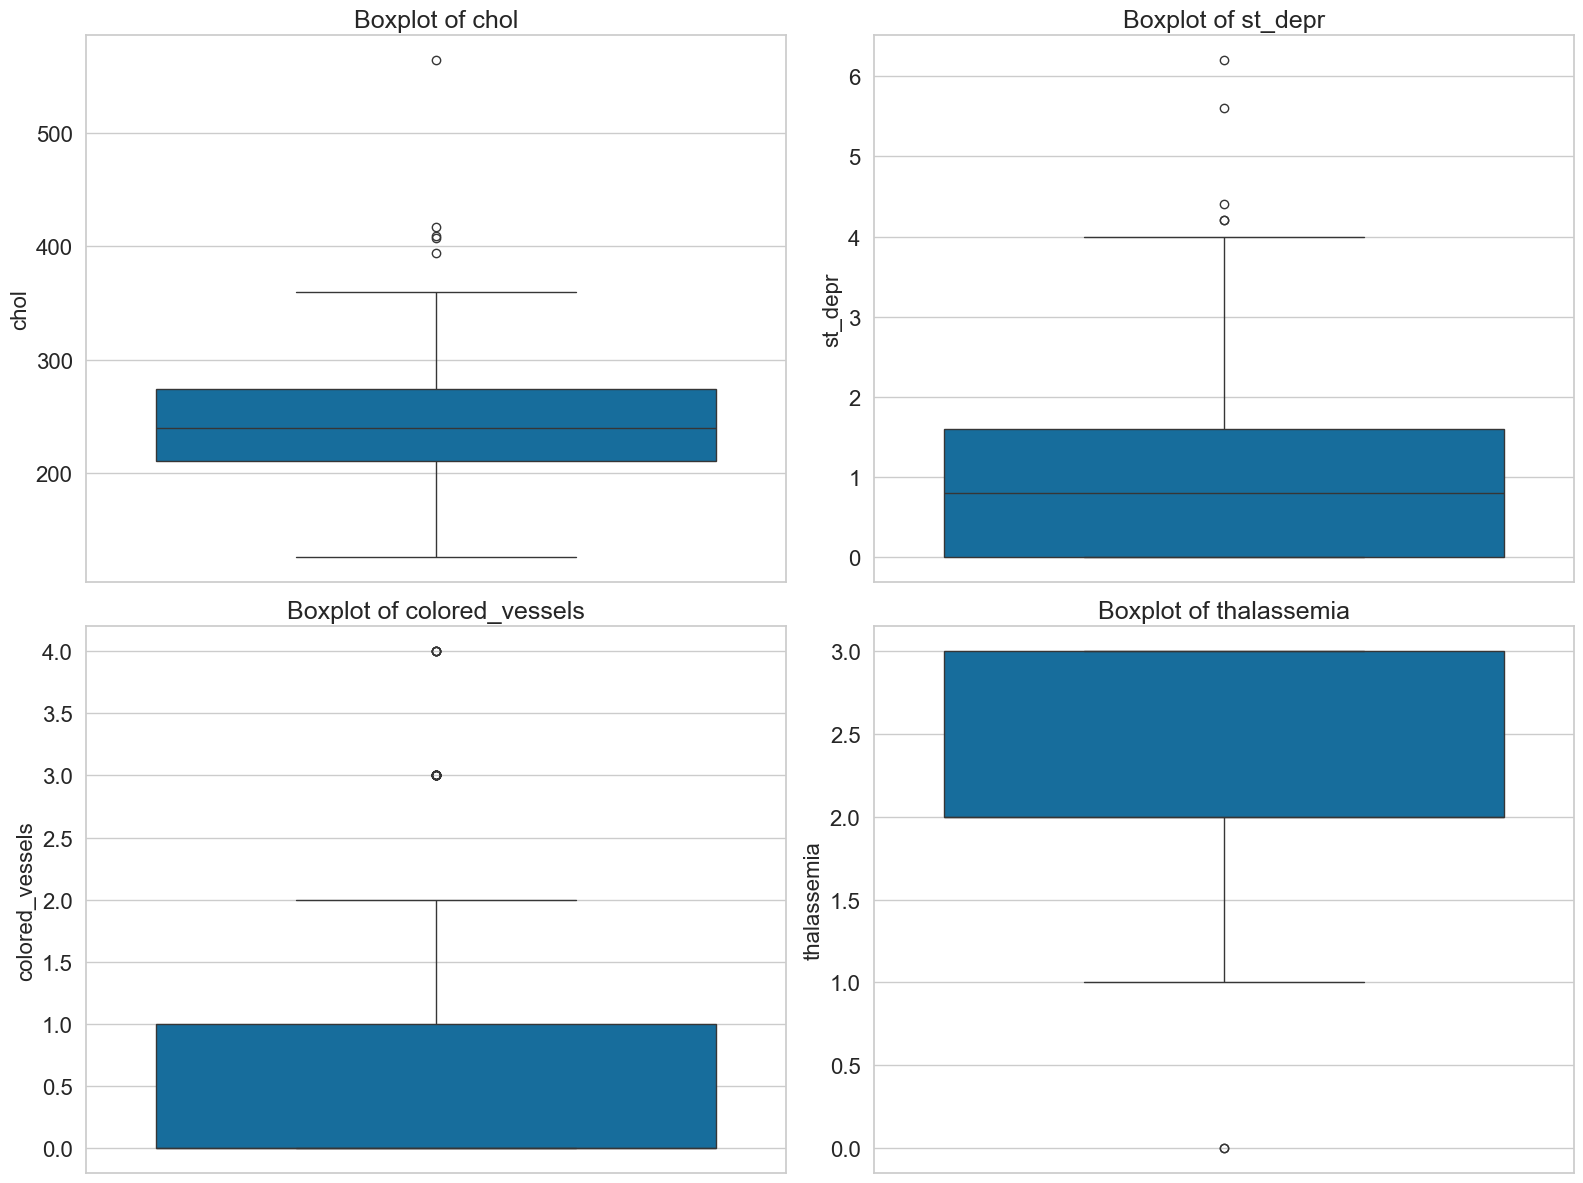

<Figure size 1200x800 with 0 Axes>

In [117]:
fts_outliers =  ['chol', 'st_depr', 'colored_vessels', 'thalassemia']

figs, axes = plt.subplots(2, 2, figsize = (16,12))

for i, col in enumerate(fts_outliers):
    sns.boxplot(df[col], ax = axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot of {col}', fontsize = 18)

# sns.set(palette = 'pastel', rc = {"figure.figsize": (12,8), \
#                                   "axes.titlesize" : 18, \
# "axes.labelsize" : 16, \
# "xtick.labelsize" : 16, \
# "ytick.labelsize" : 16 })

# chol = sns.boxplot(df['chol'])
plt.tight_layout()
plt.show()
plt.savefig('outliers.png', dpi=300, bbox_inches='tight')

## Exercise 7.03: Plotting the distributions & relationships between specific features

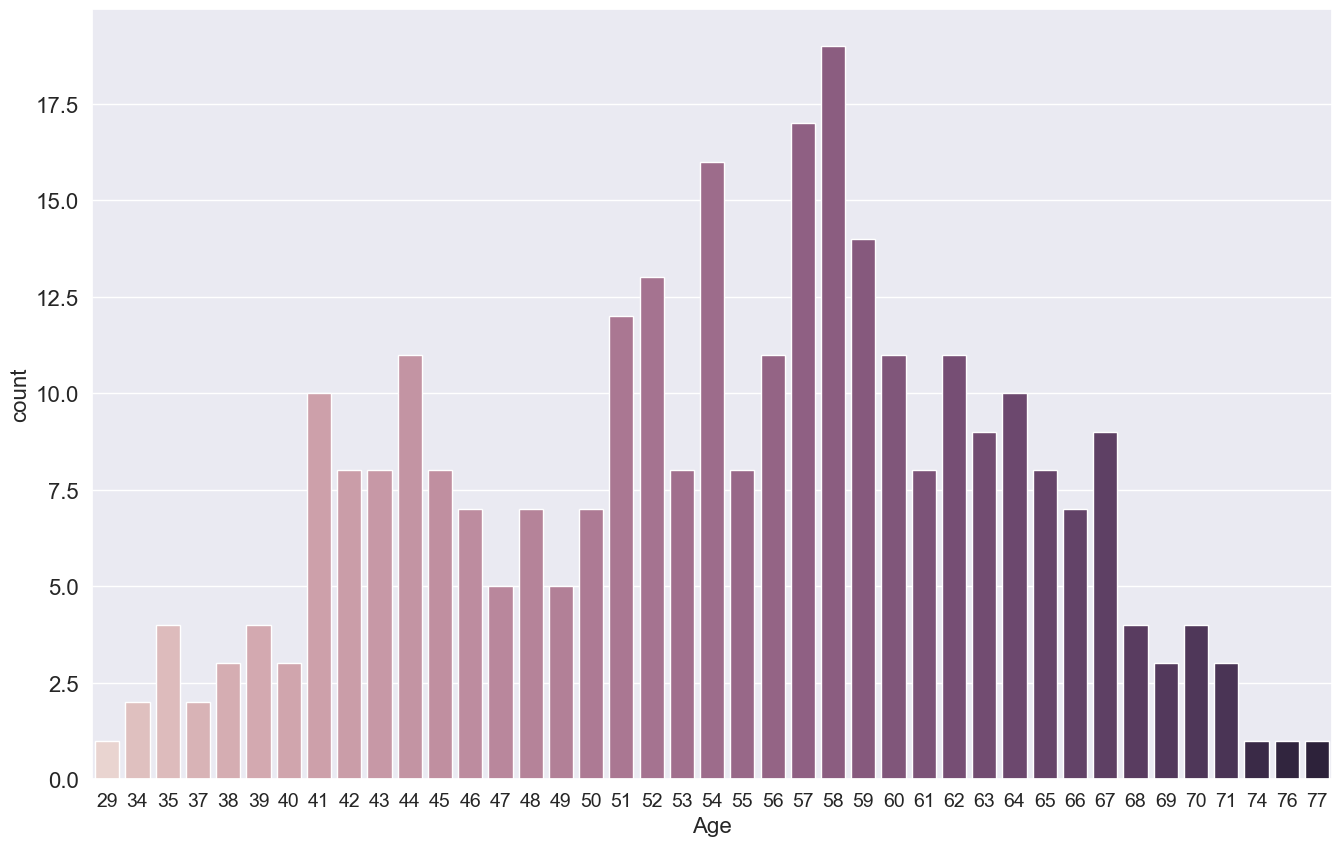

<Figure size 1600x1000 with 0 Axes>

In [118]:
sns.set(palette = 'pastel', rc = {"figure.figsize": (16,10), \
                                  "axes.titlesize" : 18, \
"axes.labelsize" : 16, \
"xtick.labelsize" : 14, \
"ytick.labelsize" : 16 })


g = sns.countplot(x = 'age', data = df, hue = 'age', legend = False)
plt.xlabel('Age')

plt.show()
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')

In [119]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

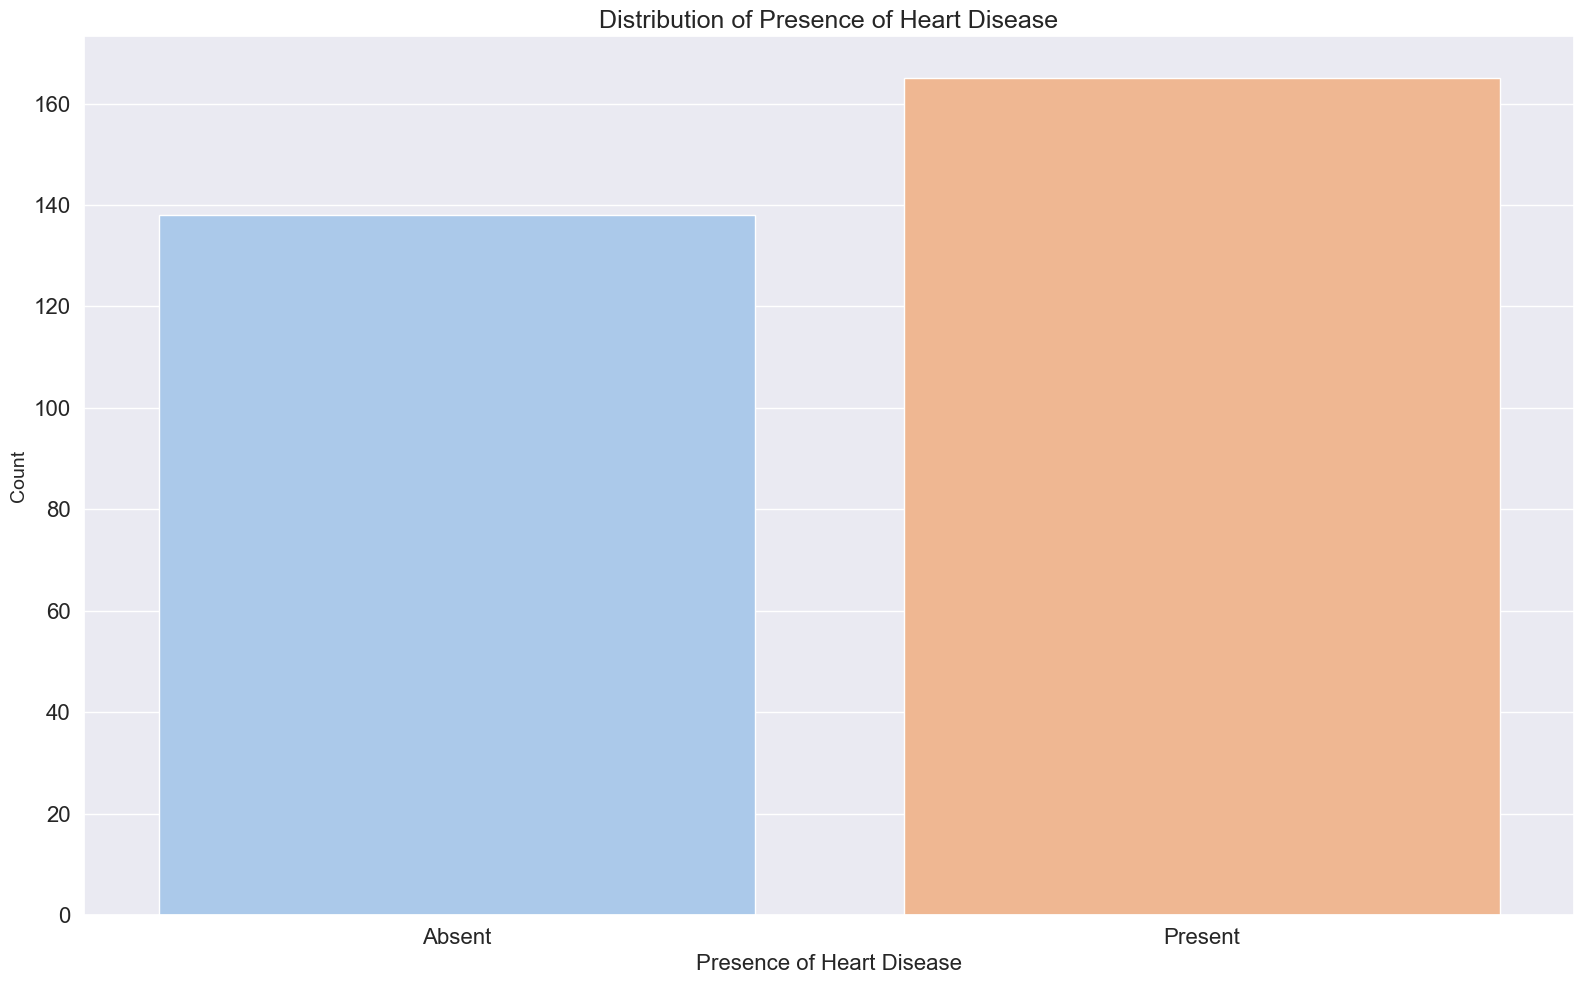

In [120]:
a = sns.countplot(x = 'target', data = df, hue= 'target', palette='pastel', legend = False)

a.set_title('Distribution of Presence of Heart Disease')
a.set_xticks([0, 1])
a.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.xlabel("Presence of Heart Disease", fontsize = 16)
plt.ylabel("Count", fontsize = 14)

plt.tight_layout()
plt.savefig('heart_disease_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [121]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

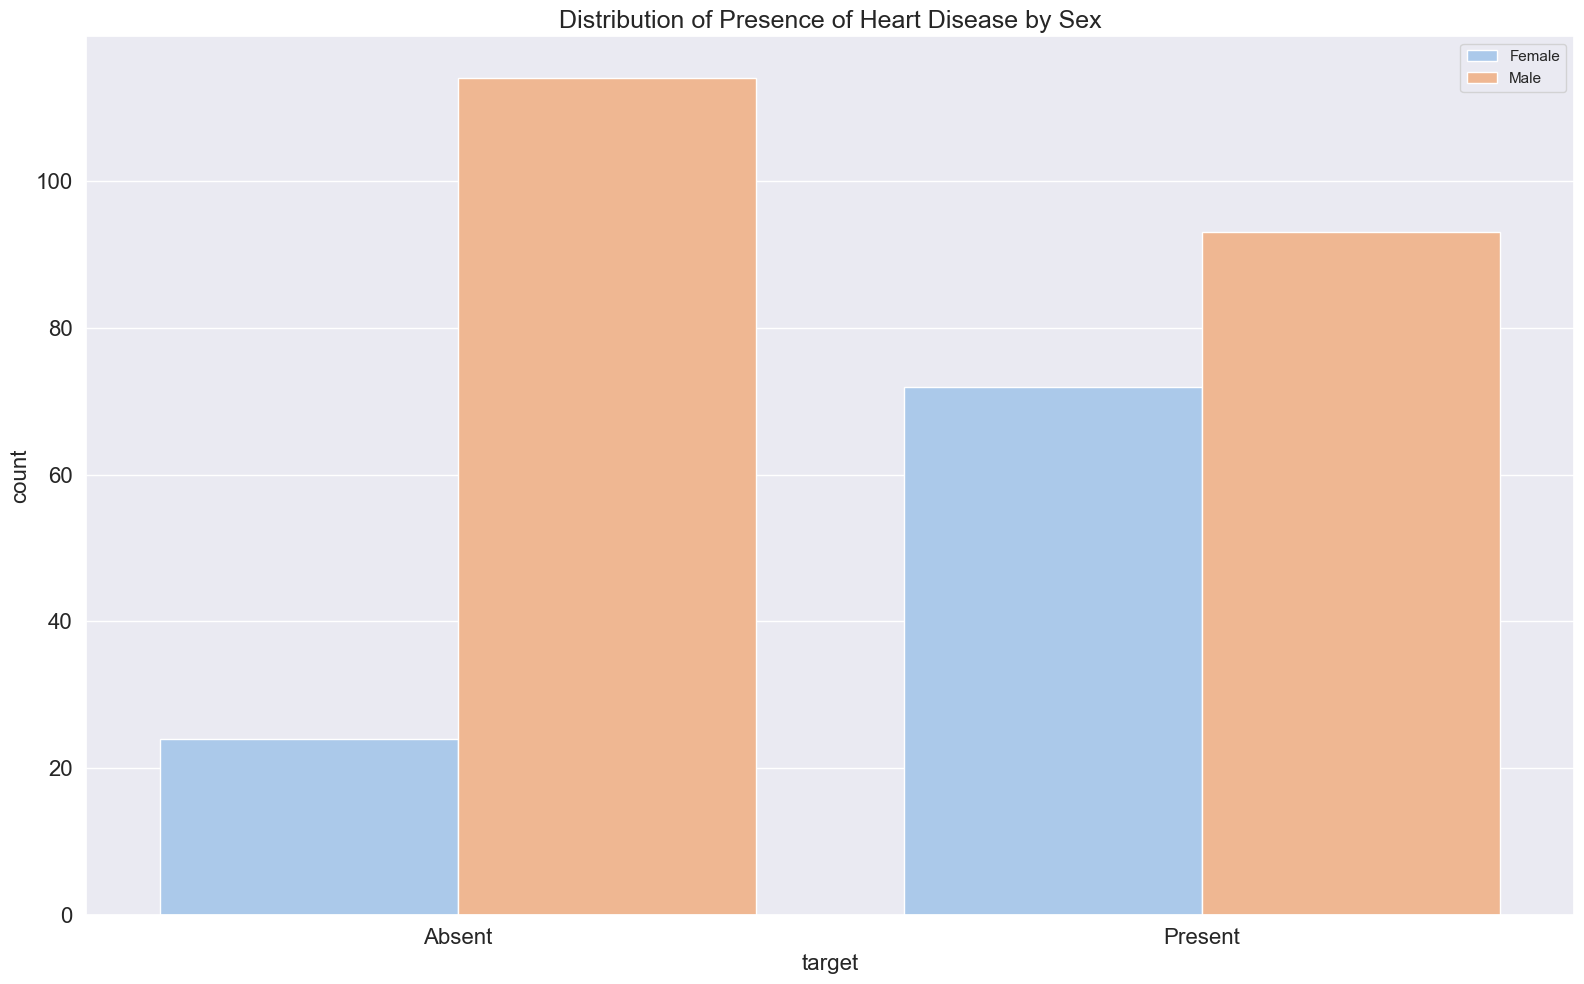

<Figure size 1600x1000 with 0 Axes>

In [122]:
b = sns.countplot(x = 'target', data = df, hue = 'sex', palette='pastel', legend = False)

b.set_title('Distribution of Presence of Heart Disease by Sex')

b.set_xticks([0, 1])
b.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.legend(labels=['Female', 'Male'])
plt.tight_layout()
plt.show()
plt.savefig('heart_disease_by_sex.png', dpi=300, bbox_inches='tight')

### Activity 7.02: Plotting Distributions and Relationships between Columns with
Respect to the Target Colum

In [123]:
df.chest_pain.value_counts()

chest_pain
0    143
2     87
1     50
3     23
Name: count, dtype: int64

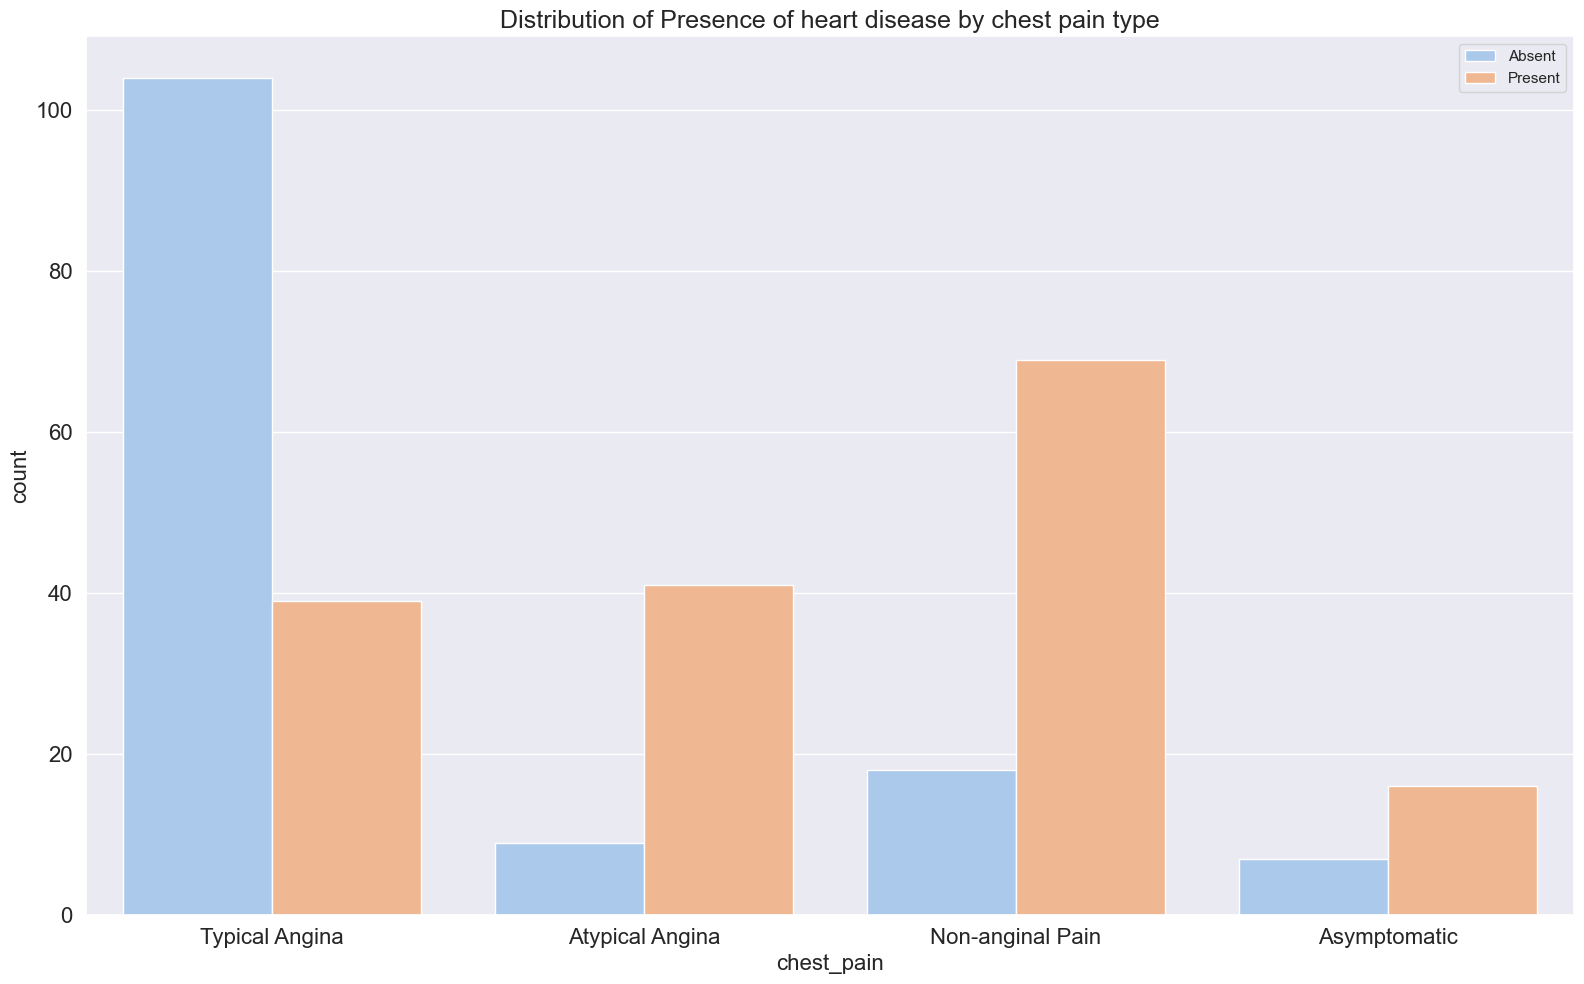

<Figure size 1600x1000 with 0 Axes>

In [124]:
c = sns.countplot(x = 'chest_pain', data = df, hue = 'target', palette='pastel', legend = False)

c.set_title('Distribution of Presence of heart disease by chest pain type')
c.set_xticks([0, 1, 2, 3])
c.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()
plt.savefig('heart_disease_by_chest_pain.png', dpi=300, bbox_inches='tight')

In [125]:
df.colored_vessels.value_counts()

colored_vessels
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64

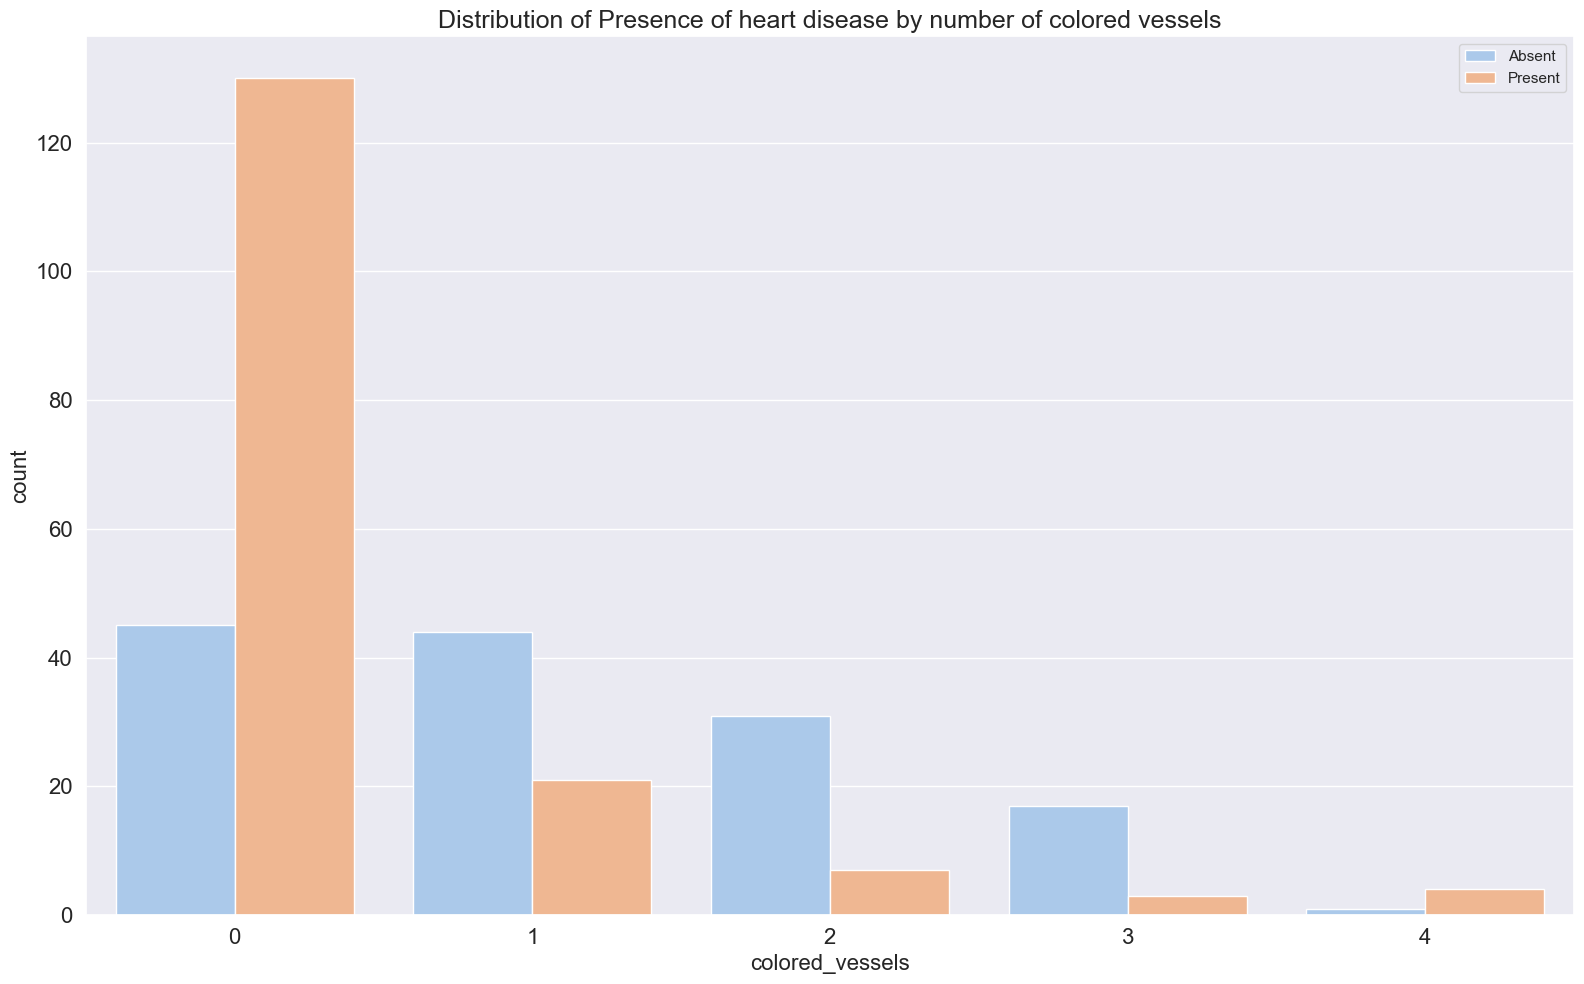

In [126]:
d = sns.countplot(x = 'colored_vessels', data= df, hue='target', palette='pastel', legend = False)
d.set_title('Distribution of Presence of heart disease by number of colored vessels')
d.set_xticks([0, 1, 2, 3, 4])
d.set_xticklabels(['0', '1', '2', '3', '4'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.savefig('heart_disease_by_colored_vessels.png', dpi=300, bbox_inches='tight')
plt.show()

In [127]:
df.slope.value_counts()

slope
2    142
1    140
0     21
Name: count, dtype: int64

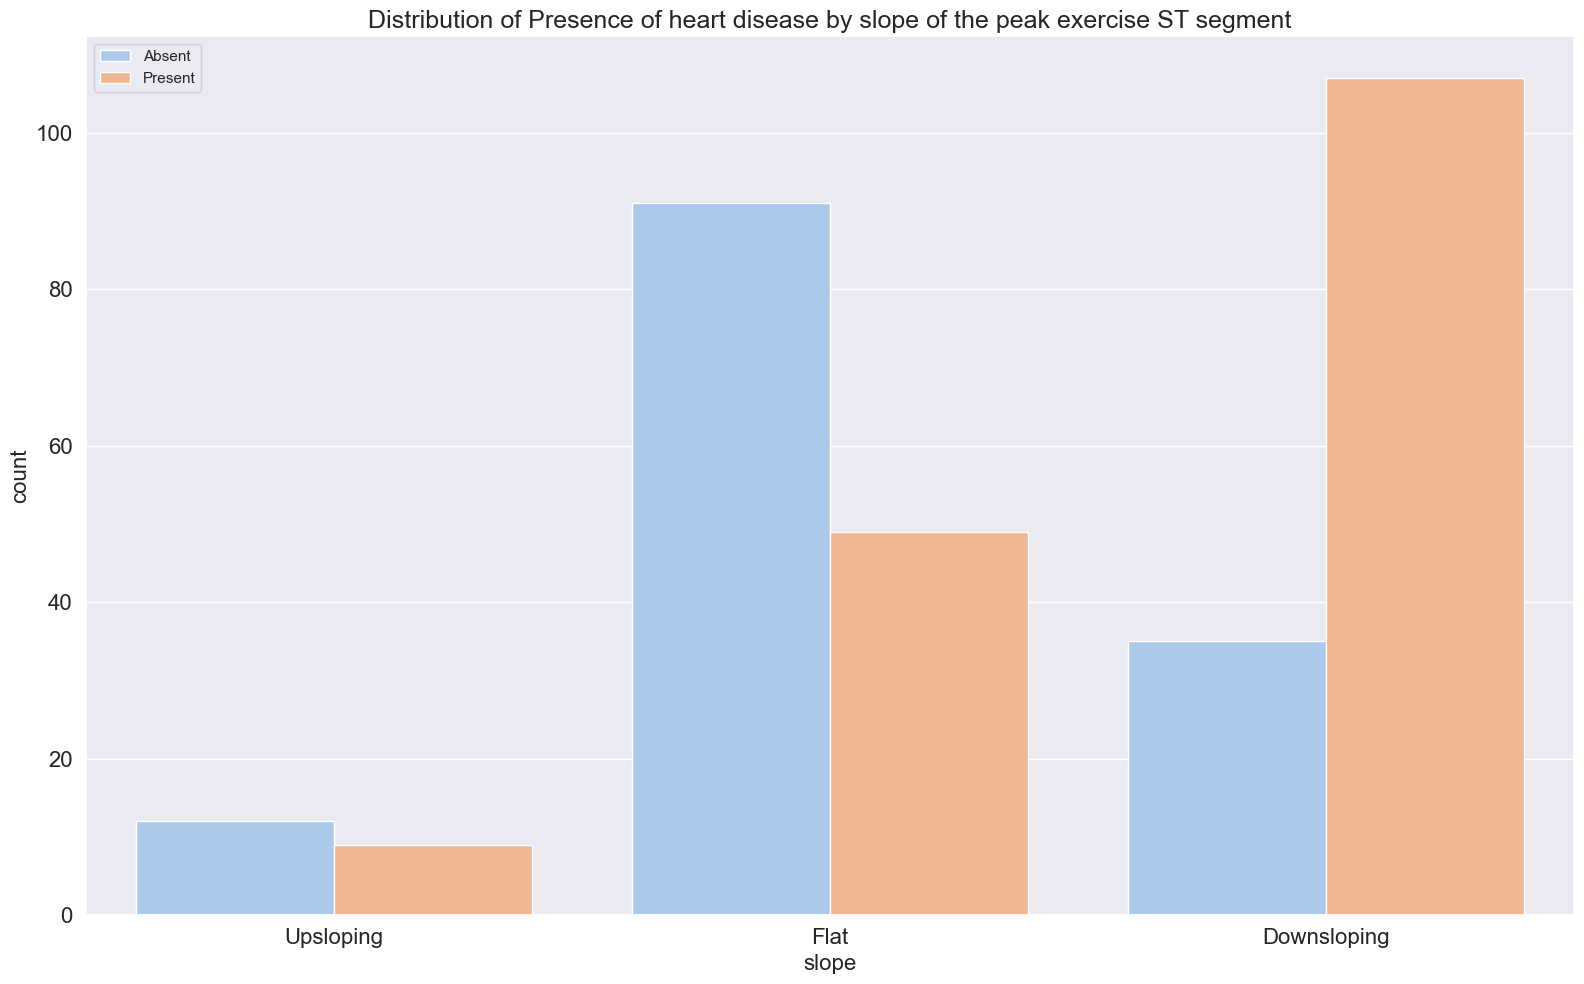

In [128]:
e = sns.countplot(x = 'slope', data = df, hue = 'target', palette='pastel', legend = False)
e.set_title('Distribution of Presence of heart disease by slope of the peak exercise ST segment')
e.set_xticks([0, 1, 2])
e.set_xticklabels(['Upsloping', 'Flat', 'Downsloping'], fontsize = 16)
plt.legend(labels=['Absent', 'Present'])
plt.tight_layout() 
plt.savefig('heart_disease_by_slope.png', dpi=300, bbox_inches='tight') 
plt.show()

## Exercise 7.04: Plotting the Relationship between the Presence of Heart Disease
and Maximum Recorded Heart Rate

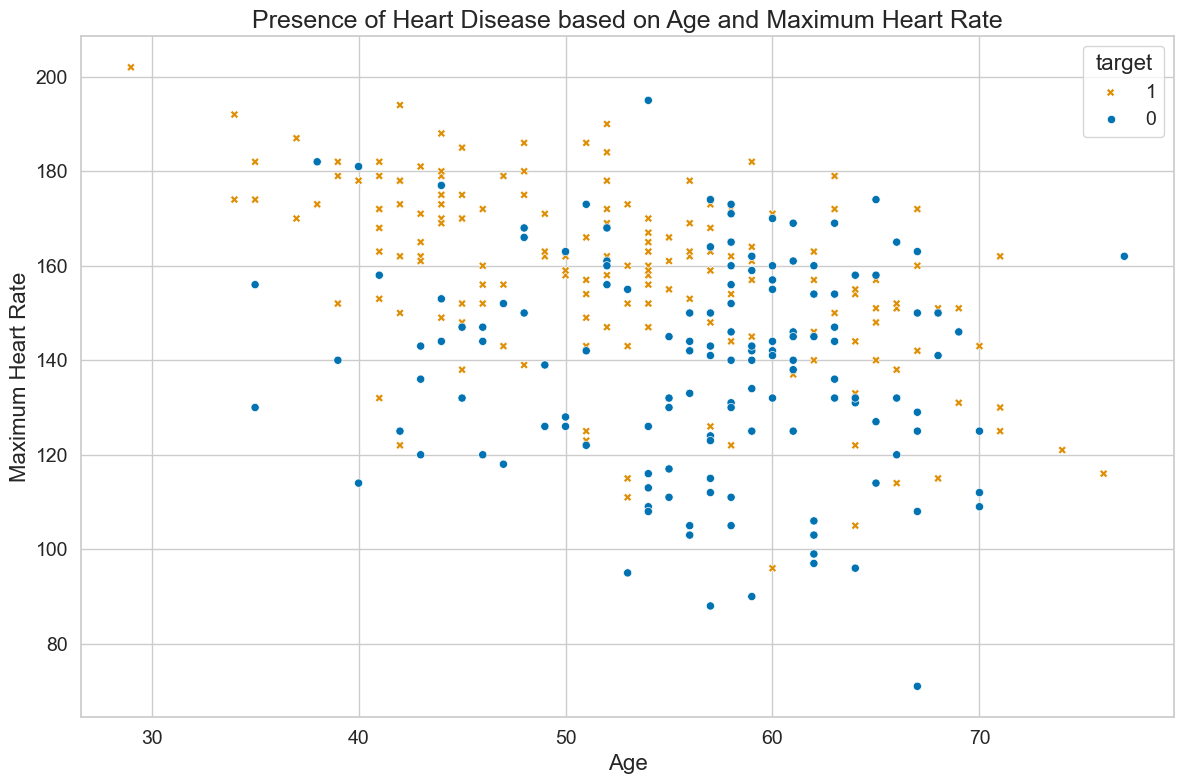

In [129]:
sns.set(style = 'whitegrid', palette = 'colorblind', rc = {"figure.figsize": (12,8), "axes.titlesize" : 18, \
        "axes.labelsize" : 16, "xtick.labelsize" : 16, \
        "ytick.labelsize" : 16 }
)

f = sns.scatterplot(x = 'age', y ='max_hr', hue='target', style='target',data=df, palette= 'colorblind', s=35)
f.set_title('Presence of Heart Disease based on Age and '\
            'Maximum Heart Rate')

f.legend(title='target', labels=["1", "0"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.tight_layout()
plt.savefig('heart_disease_by_age_max_hr.png', dpi=300, bbox_inches='tight')
plt.show()

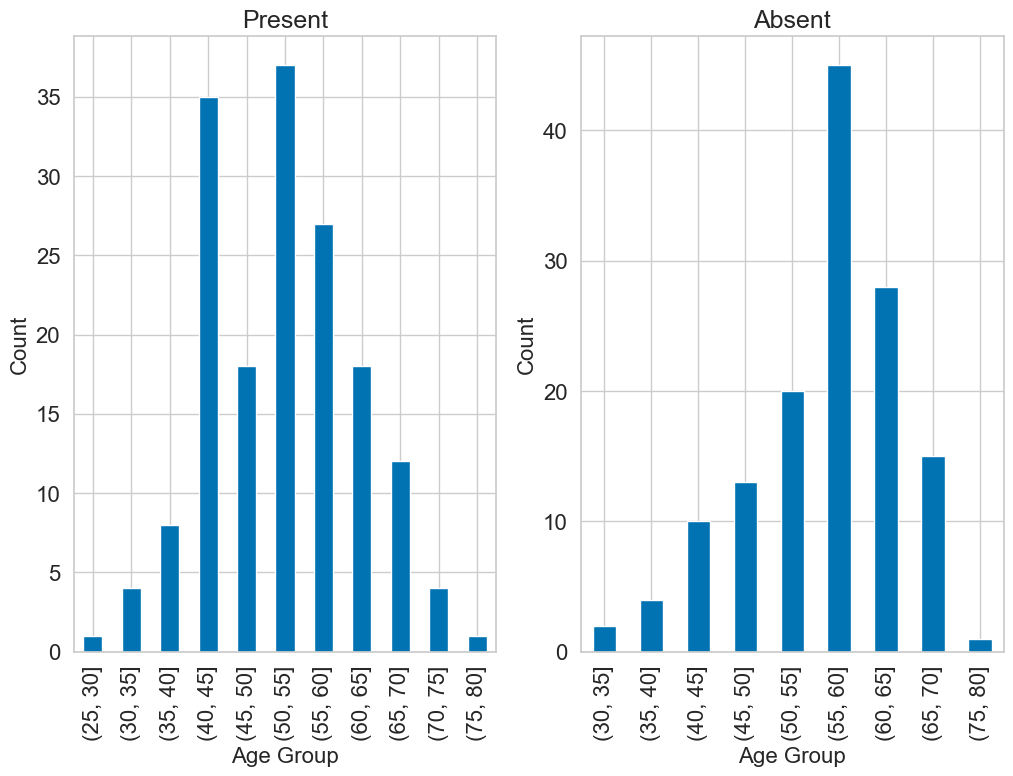

In [130]:

df['age_category'] = pd.cut(df.age, \
                            bins = list(np.arange(25, 85, 5)))

plt.subplot(121)
df[df.target == 1].groupby('age_category')['age']\
                    .count().plot(kind = 'bar')
                    
plt.title('Present')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('age_category')['age']\
.count().plot(kind = 'bar')

plt.title('Absent')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.savefig('heart_disease_by_age.png', dpi=300, bbox_inches='tight')
plt.show()



### Activity 7.03: Plotting the Relationship between the Presence of Heart Disease
and the Cholesterol Column

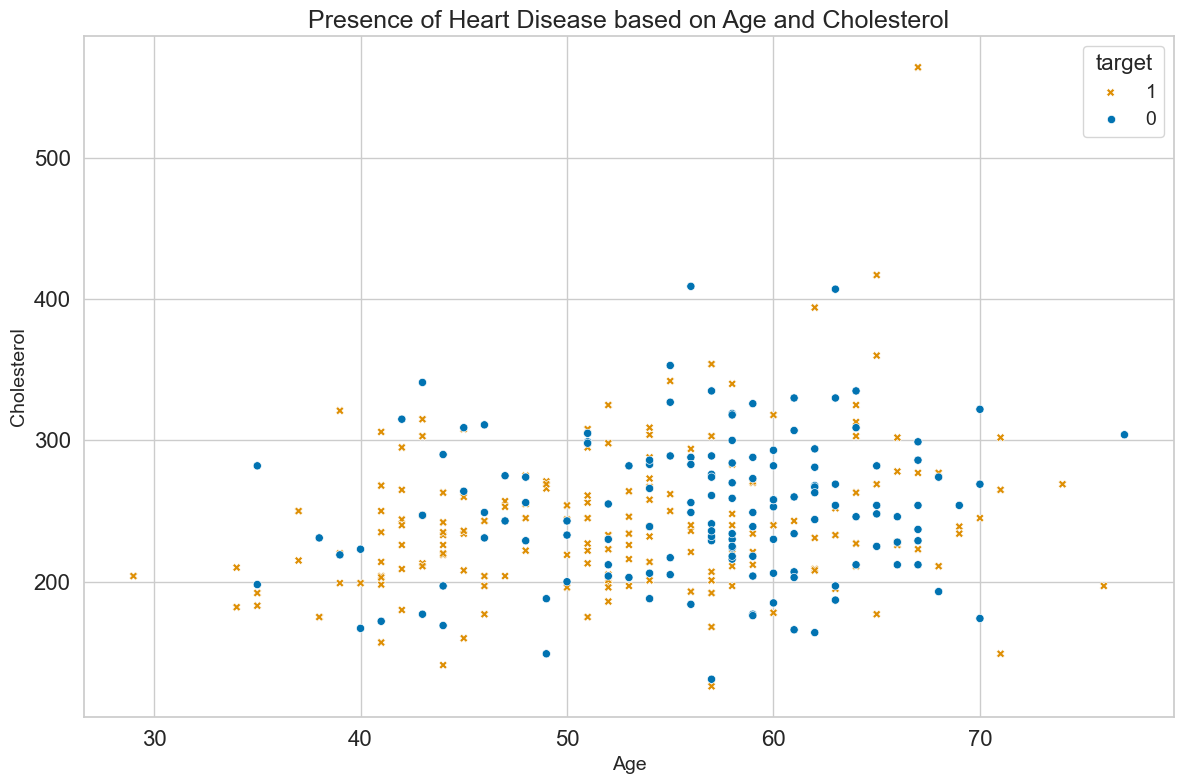

In [131]:
g = sns.scatterplot(x = 'age', y ='chol', hue ='target', style = 'target', data = df, palette = 'colorblind', s = 35)
g.set_title("Presence of Heart Disease based on Age and Cholesterol")

plt.xlabel('Age', fontsize = 14)
plt.ylabel('Cholesterol', fontsize = 14)
g.legend(title = 'target', labels = ["1", "0"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.tight_layout()
plt.savefig('heart_disease_by_age_chol.png', dpi=300, bbox_inches='tight')
plt.show()

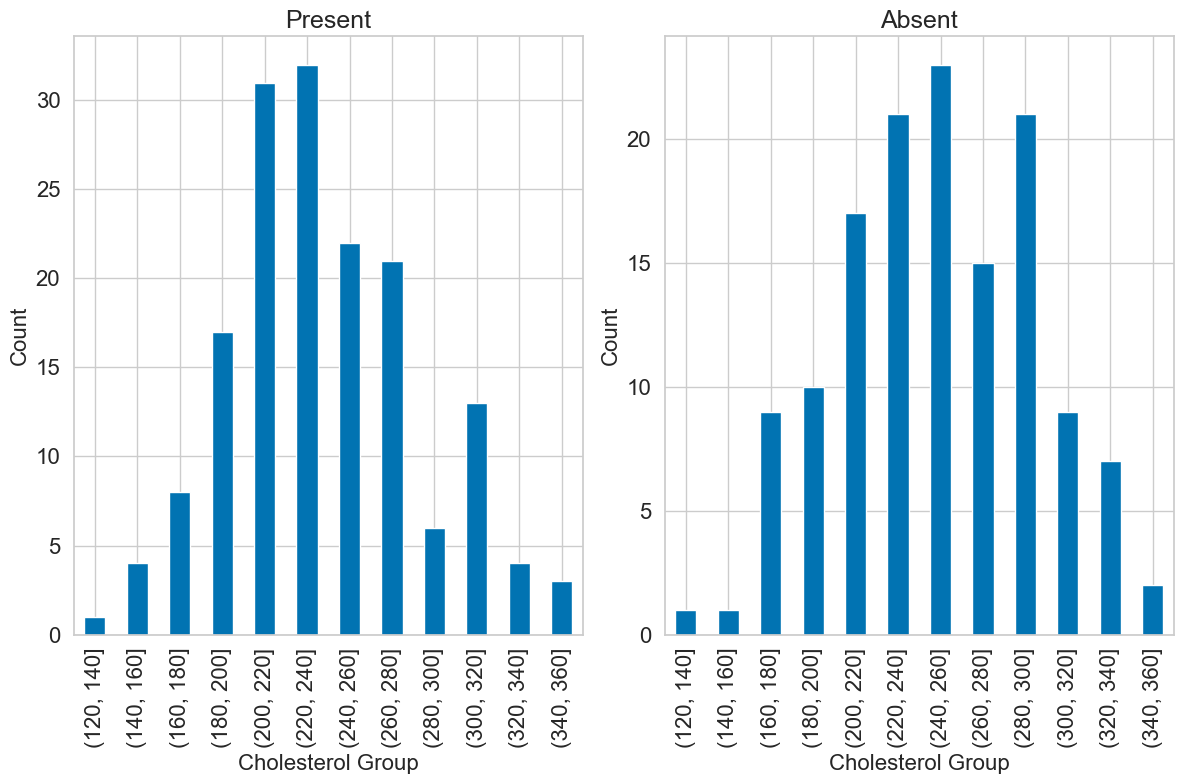

In [132]:
df['chol_category'] = pd.cut(df.chol, bins = list(np.arange(120, 380, 20)))

#plt.figure(figsize=(10,5))
plt.subplot(121)
df[df.target == 1].groupby('chol_category')['chol']\
                    .count().plot(kind = 'bar')
plt.title('Present')
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('chol_category')['chol']\
.count().plot(kind = 'bar')
plt.title('Absent') 
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('heart_disease_by_cholesterol.png', dpi=300, bbox_inches='tight')
plt.show()

## Exercise 7.05: Observing Correlations with a Heatmap

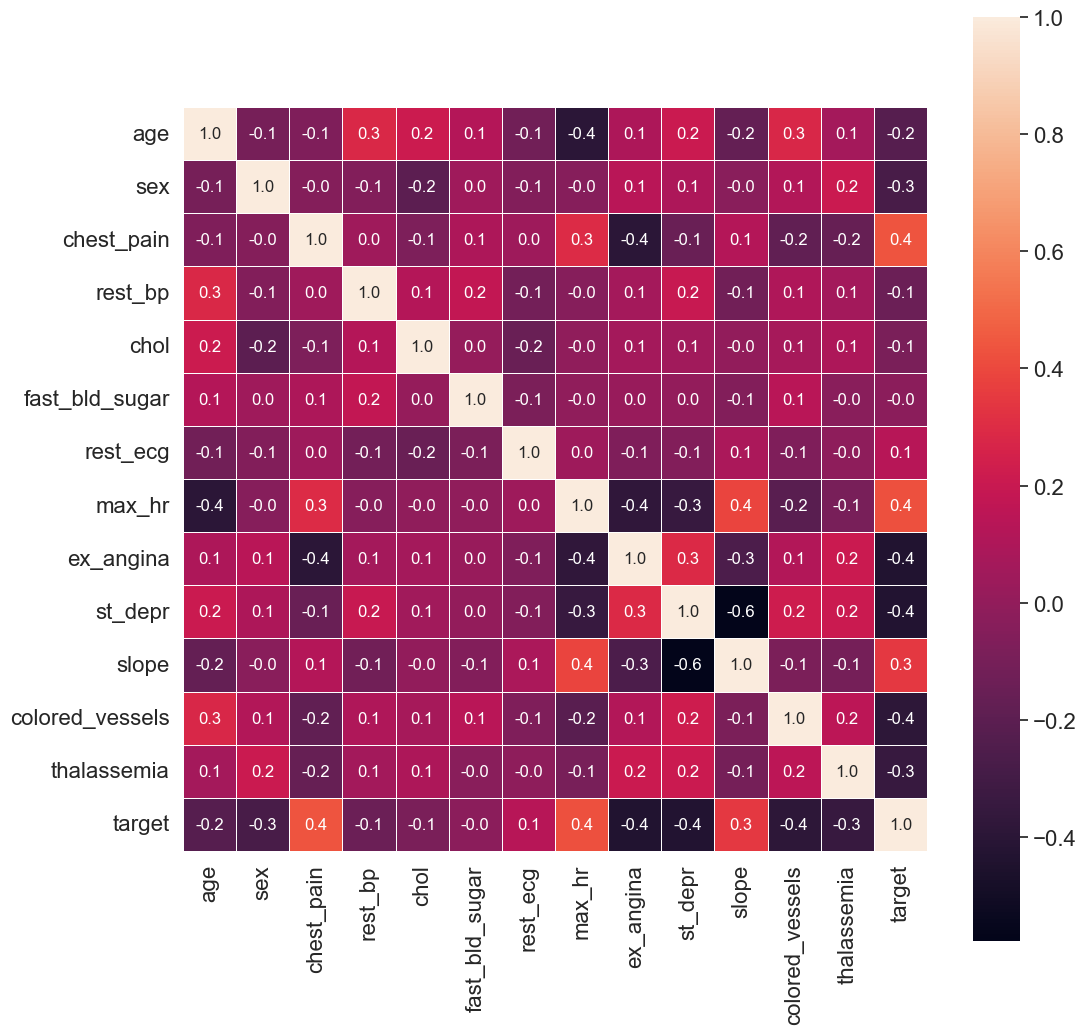

In [133]:
cols = [
    'age', 'sex', 'chest_pain', 'rest_bp', 'chol',
    'fast_bld_sugar', 'rest_ecg', 'max_hr',
    'ex_angina', 'st_depr', 'slope',
    'colored_vessels', 'thalassemia', 'target'
]

corr = df[cols].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True,fmt=".1f", linewidths=0.5, cmap="rocket", square=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()